# DATE3 实验7：四个完整MoE Transformer Block端到端实验

六组与Exp5/Exp6完全一致。NoPF组是映射消融，固定PF组是非协同消融，PIVOT是完整方案。
四个连续Block采用不同路由阶段并共享一个在线控制器；固定预取只允许使用独立校准后冻结的
一组Window/Chunk，且任何方案都不能跨Router边界预取。端到端周期由四组非MoE层完整周期
与方案相关的MoE+EP关键路径组成。


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    display = print
ROOT=Path.cwd().resolve().parent if Path.cwd().name=='fig' else Path.cwd().resolve()
OUT=ROOT/'outputs/DATE3/exp7'; FIG=ROOT/'fig/DATE3'; FIG.mkdir(parents=True,exist_ok=True)
MODELS=['HMoE','Mixtral','MoDSE','Switchtrans']
SCHEMES=['Static-555-NoPF','Static-Opt-NoPF','Dynamic-NoPF',
         'Static-Opt-FixedPF','Dynamic-FixedPF','PIVOT']
LABELS=['Static-555','Static-Opt','Dynamic-NoPF','Static-Opt+FixedPF','Dynamic-FixedPF','PIVOT']
COLORS=['#9E9E9E','#F28E2B','#4E79A7','#EDC948','#76B7B2','#59A14F']
d=pd.read_csv(OUT/'end_to_end_summary.csv')
assert len(d)==len(MODELS)*len(SCHEMES)
assert set(d.model)==set(MODELS) and set(d.policy_name)==set(SCHEMES)
assert not d.duplicated(['model','policy_name']).any()
assert set(d.block_count)=={4}
assert set(d.approximation_scope)=={'four_complete_moe_transformer_blocks'}
for model in MODELS:
    payload=json.loads((ROOT/f'configs/MoE/DATE3/end_to_end/{model}.json').read_text())
    multi=payload['multi_layer_prefetch']; policy=payload['coverage_accuracy_policy']
    assert multi['enabled'] and multi['layer_count']==4
    assert multi['router_boundary_prefetch']=='forbidden'
    assert (policy['reference_window'],policy['reference_chunk'])==(2,8)
wide=lambda f:d.pivot(index='model',columns='policy_name',values=f).reindex(MODELS,columns=SCHEMES)
e2e=wide('approx_block_total_cycles'); moe=wide('moe_ep_cycles')
speed=e2e['Static-555-NoPF'].to_numpy()[:,None]/e2e
print(f'Loaded {len(d)} Exp7 rows.')


Loaded 24 Exp7 rows.


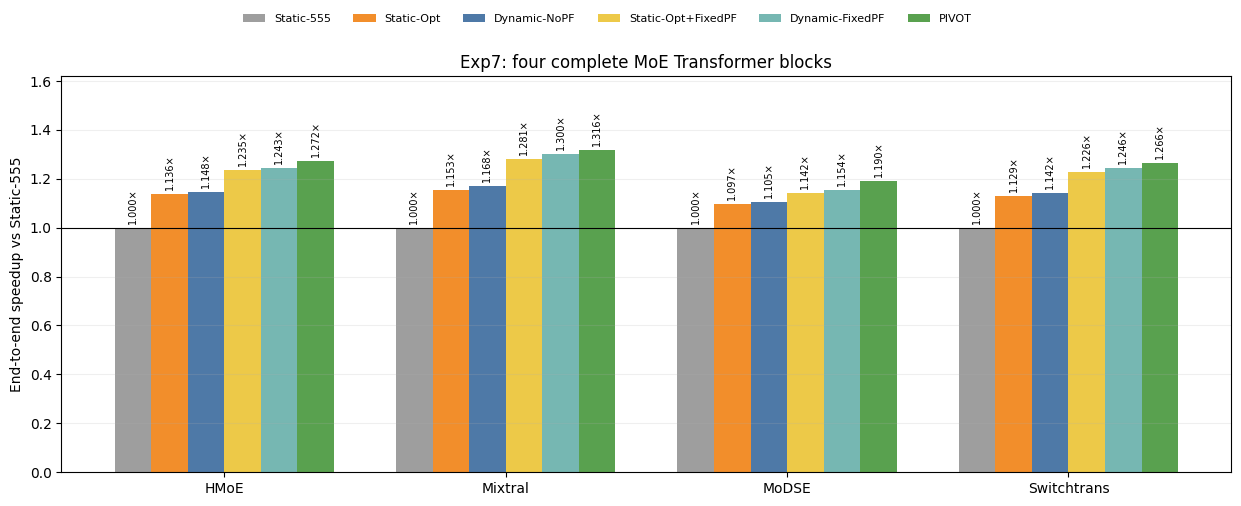

In [2]:
x=np.arange(len(MODELS)); width=.13
fig,ax=plt.subplots(figsize=(13,6.0))
for i,(scheme,label,color) in enumerate(zip(SCHEMES,LABELS,COLORS)):
    bars=ax.bar(x+(i-2.5)*width,speed[scheme],width,label=label,color=color)
    ax.bar_label(bars,labels=[f'{v:.3f}×' for v in speed[scheme]],padding=3,fontsize=7,rotation=90)
ax.axhline(1,color='black',lw=.8); ax.set_xticks(x,MODELS)
ax.set_ylabel('End-to-end speedup vs Static-555')
ax.set_title('Exp7: four complete MoE Transformer blocks')
ax.set_ylim(0,float(speed.max().max())*1.23)
handles,legend_labels=ax.get_legend_handles_labels()
fig.legend(handles,legend_labels,ncol=6,frameon=False,fontsize=8,
           loc='upper center',bbox_to_anchor=(.5,.90))
ax.grid(axis='y',alpha=.2)
fig.subplots_adjust(top=.78,bottom=.12,left=.08,right=.98)
plt.savefig(FIG/'exp7_end_to_end_speedup.pdf',bbox_inches='tight')
plt.savefig(FIG/'exp7_end_to_end_speedup.png',dpi=220,bbox_inches='tight'); plt.show(); plt.close(fig)


### 图4(b)：四个完整 Transformer block 的端到端加速比，包含六个可部署方案。

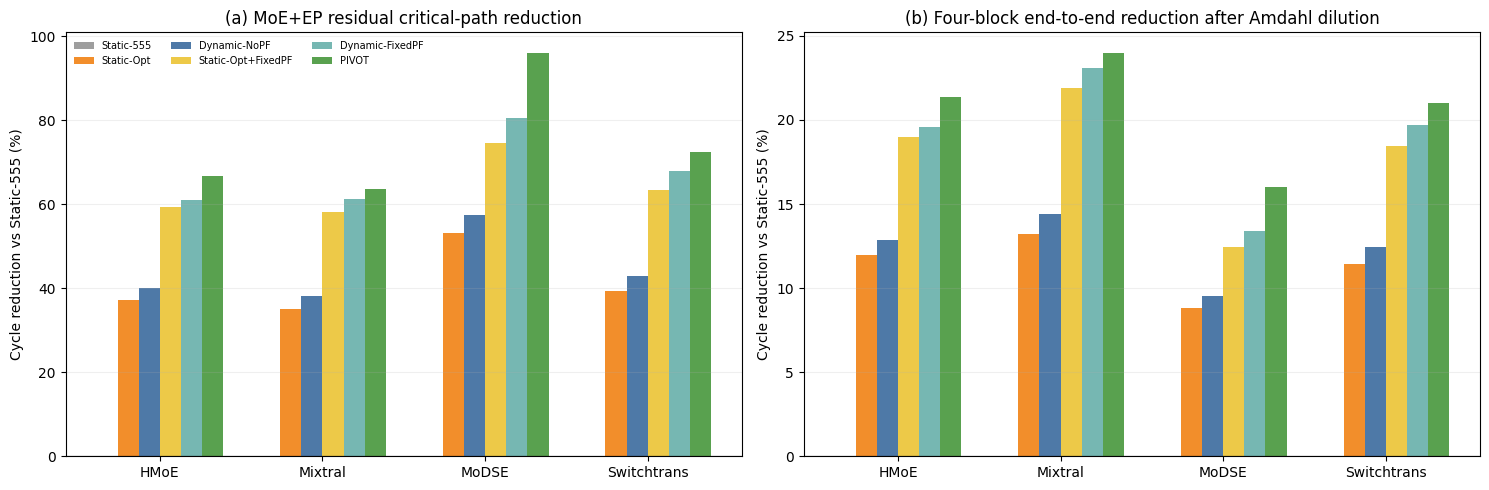

In [3]:
moe_reduction=(1-moe/moe['Static-555-NoPF'].to_numpy()[:,None])*100
e2e_reduction=(1-e2e/e2e['Static-555-NoPF'].to_numpy()[:,None])*100
fig,axes=plt.subplots(1,2,figsize=(15,5))
for i,(scheme,label,color) in enumerate(zip(SCHEMES,LABELS,COLORS)):
    axes[0].bar(x+(i-2.5)*width,moe_reduction[scheme],width,label=label,color=color)
    axes[1].bar(x+(i-2.5)*width,e2e_reduction[scheme],width,label=label,color=color)
for ax,title in zip(axes,['(a) MoE+EP residual critical-path reduction',
                          '(b) Four-block end-to-end reduction after Amdahl dilution']):
    ax.axhline(0,color='black',lw=.8); ax.set_xticks(x,MODELS); ax.set_title(title)
    ax.set_ylabel('Cycle reduction vs Static-555 (%)'); ax.grid(axis='y',alpha=.2)
axes[0].legend(ncol=3,frameon=False,fontsize=7)
plt.tight_layout(); plt.savefig(FIG/'exp7_moe_vs_end_to_end.pdf',bbox_inches='tight')
plt.savefig(FIG/'exp7_moe_vs_end_to_end.png',dpi=220,bbox_inches='tight'); plt.show(); plt.close(fig)


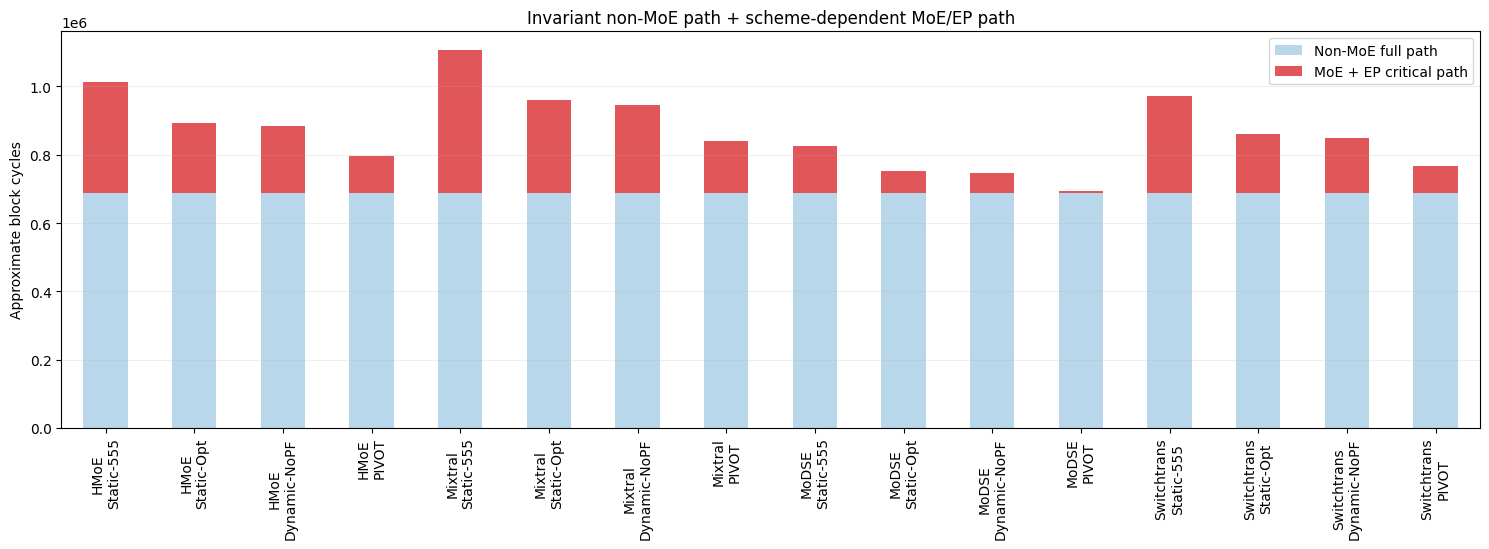

In [4]:
selected=d[d.policy_name.isin(['Static-555-NoPF','Static-Opt-NoPF','Dynamic-NoPF','PIVOT'])].copy()
selected['label']=selected.model+'\n'+selected.policy_name.map(dict(zip(SCHEMES,LABELS)))
selected=selected.set_index('label')
fig,ax=plt.subplots(figsize=(15,5.6))
selected[['non_moe_full_cycles','moe_ep_cycles']].plot(kind='bar',stacked=True,ax=ax,
                                                       color=['#B9D7EA','#E15759'])
ax.set_ylabel('Approximate block cycles'); ax.set_xlabel('')
ax.set_title('Invariant non-MoE path + scheme-dependent MoE/EP path')
ax.legend(['Non-MoE full path','MoE + EP critical path']); ax.grid(axis='y',alpha=.2)
plt.tight_layout(); plt.savefig(FIG/'exp7_block_decomposition.pdf',bbox_inches='tight')
plt.savefig(FIG/'exp7_block_decomposition.png',dpi=220,bbox_inches='tight'); plt.show(); plt.close(fig)


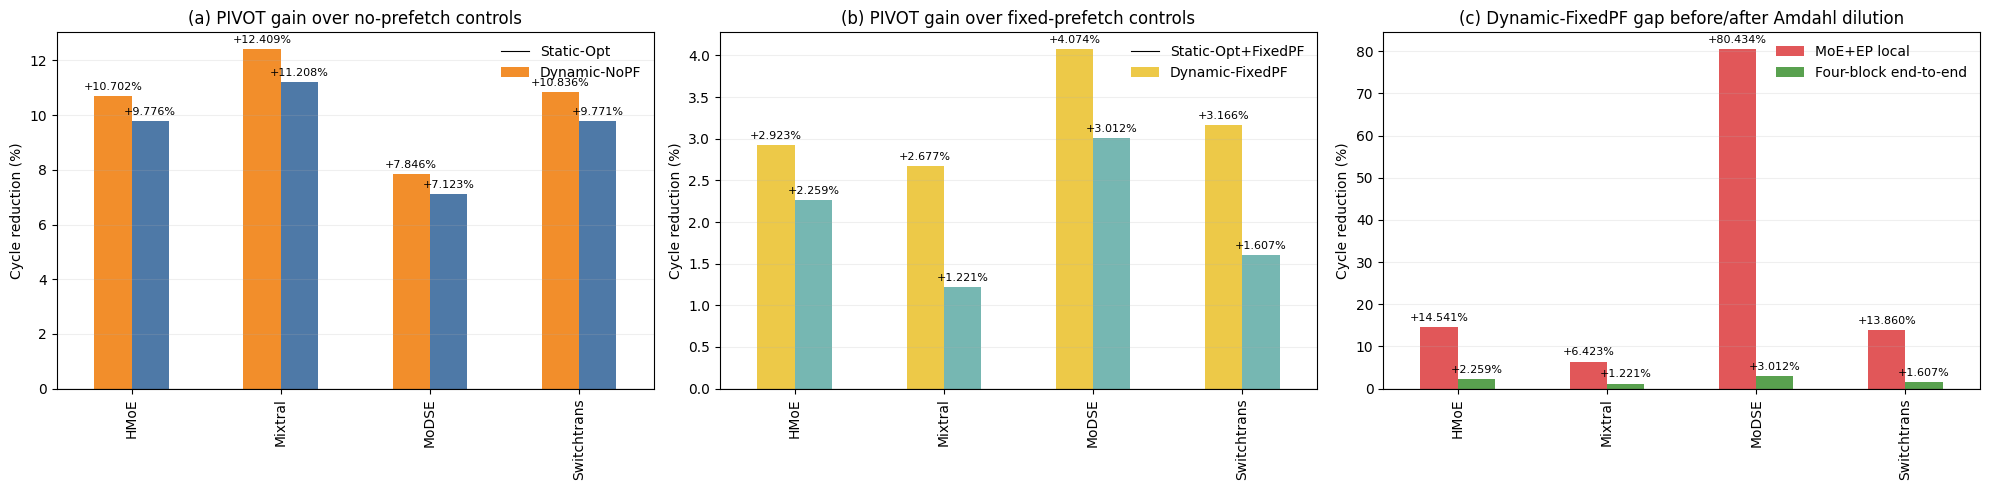

,Static-Opt-NoPF,Dynamic-NoPF,Static-Opt-FixedPF,Dynamic-FixedPF
HMoE,10.7017,9.7763,2.9234,2.2591
Mixtral,12.4093,11.2080,2.6766,1.2209
MoDSE,7.8455,7.1229,4.0735,3.0116
Switchtrans,10.8356,9.7713,3.1662,1.6072


In [5]:
# Magnify the differences hidden by the full-speedup plot. Positive means PIVOT
# is faster; negative means the named control is faster.
controls=['Static-Opt-NoPF','Dynamic-NoPF','Static-Opt-FixedPF','Dynamic-FixedPF']
control_labels=['Static-Opt','Dynamic-NoPF','Static-Opt+FixedPF','Dynamic-FixedPF']
gains=pd.DataFrame({name:(1-e2e.PIVOT/e2e[name])*100 for name in controls},index=MODELS)
local_vs_dynamic_fixed=(1-moe.PIVOT/moe['Dynamic-FixedPF'])*100
fig,axes=plt.subplots(1,3,figsize=(20,5.0))
gains[['Static-Opt-NoPF','Dynamic-NoPF']].plot(kind='bar',ax=axes[0],
    color=['#F28E2B','#4E79A7'])
gains[['Static-Opt-FixedPF','Dynamic-FixedPF']].plot(kind='bar',ax=axes[1],
    color=['#EDC948','#76B7B2'])
pd.DataFrame({'MoE+EP local':local_vs_dynamic_fixed,
              'Four-block end-to-end':gains['Dynamic-FixedPF']}).plot(
    kind='bar',ax=axes[2],color=['#E15759','#59A14F'])
for ax,title in zip(axes,['(a) PIVOT gain over no-prefetch controls',
                          '(b) PIVOT gain over fixed-prefetch controls',
                          '(c) Dynamic-FixedPF gap before/after Amdahl dilution']):
    ax.axhline(0,color='black',lw=.8); ax.set_title(title)
    ax.set_ylabel('Cycle reduction (%)'); ax.set_xlabel('')
    ax.grid(axis='y',alpha=.2)
    for container in ax.containers:
        ax.bar_label(container,labels=[f'{bar.get_height():+.3f}%' for bar in container],
                     padding=3,fontsize=8)
axes[0].legend(['Static-Opt','Dynamic-NoPF'],frameon=False)
axes[1].legend(['Static-Opt+FixedPF','Dynamic-FixedPF'],frameon=False)
axes[2].legend(frameon=False)
plt.tight_layout(); plt.savefig(FIG/'exp7_incremental_gain.pdf',bbox_inches='tight')
plt.savefig(FIG/'exp7_incremental_gain.png',dpi=220,bbox_inches='tight'); plt.show(); plt.close(fig)
display(gains.round(4))


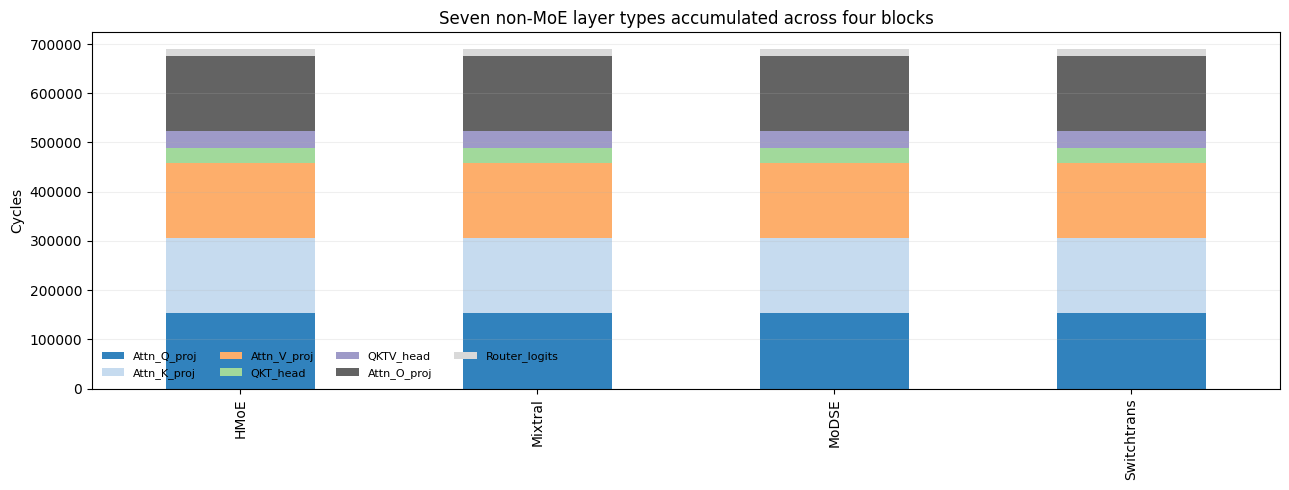

In [6]:
layers=pd.read_csv(OUT/'non_moe_layer_breakdown.csv')
layer_order=['Attn_Q_proj','Attn_K_proj','Attn_V_proj','QKT_head','QKTV_head','Attn_O_proj','Router_logits']
layer_cycles=layers.groupby(['model','base_layer']).total_cycles.sum().unstack().reindex(MODELS,columns=layer_order)
fig,ax=plt.subplots(figsize=(13,5.0))
layer_cycles.plot(kind='bar',stacked=True,ax=ax,colormap='tab20c')
ax.set_ylabel('Cycles'); ax.set_xlabel(''); ax.set_title('Seven non-MoE layer types accumulated across four blocks')
ax.legend(ncol=4,frameon=False,fontsize=8); ax.grid(axis='y',alpha=.2)
plt.tight_layout(); plt.savefig(FIG/'exp7_non_moe_breakdown.pdf',bbox_inches='tight')
plt.savefig(FIG/'exp7_non_moe_breakdown.png',dpi=220,bbox_inches='tight'); plt.show(); plt.close(fig)


In [7]:
hard_checks=pd.Series({
 'Static-Opt never exceeds Static-555':(e2e['Static-Opt-NoPF']<=e2e['Static-555-NoPF']).all(),
 'Dynamic strictly improves Static-Opt':(e2e['Dynamic-NoPF']<e2e['Static-Opt-NoPF']).all(),
 'Dynamic fixed-PF strictly improves Static fixed-PF':(e2e['Dynamic-FixedPF']<e2e['Static-Opt-FixedPF']).all(),
 'Composition identity holds':np.allclose(d.approx_block_total_cycles,d.composition_check_cycles),
 'Amdahl identity holds':np.allclose(d.end_to_end_speedup_vs_static,d.amdahl_speedup),
})
performance_checks=pd.Series({
 'PIVOT beats Dynamic-NoPF on every model':(e2e.PIVOT<e2e['Dynamic-NoPF']).all(),
 'PIVOT beats Dynamic-FixedPF on every model':(e2e.PIVOT<e2e['Dynamic-FixedPF']).all(),
 'PIVOT gains at least 1% over Dynamic-FixedPF on every model':(
     gains['Dynamic-FixedPF']>=1.0).all(),
})
display(pd.concat([hard_checks,performance_checks]).rename('pass').to_frame())
assert hard_checks.all()
display(d[['model','policy_name','moe_ep_speedup_vs_static','end_to_end_speedup_vs_static',
           'static_moe_ep_fraction']].round(4))


,pass
Static-Opt never exceeds Static-555,True
Dynamic strictly improves Static-Opt,True
Dynamic fixed-PF strictly improves Static fixed-PF,True
Composition identity holds,True
Amdahl identity holds,True
PIVOT beats Dynamic-NoPF on every model,True
PIVOT beats Dynamic-FixedPF on every model,True
PIVOT gains at least 1% over Dynamic-FixedPF on every model,True


,model,policy_name,moe_ep_speedup_vs_static,end_to_end_speedup_vs_static,static_moe_ep_fraction
0,HMoE,Static-555-NoPF,1.0000,1.0000,0.3206
1,HMoE,Static-Opt-NoPF,1.5947,1.1358,0.3206
2,HMoE,Dynamic-NoPF,1.6697,1.1475,0.3206
3,HMoE,Static-Opt-FixedPF,2.4569,1.2347,0.3206
4,HMoE,Dynamic-FixedPF,2.5652,1.2432,0.3206
5,HMoE,PIVOT,3.0016,1.2719,0.3206
6,Mixtral,Static-555-NoPF,1.0000,1.0000,0.3769
7,Mixtral,Static-Opt-NoPF,1.5417,1.1527,0.3769
8,Mixtral,Dynamic-NoPF,1.6194,1.1685,0.3769
9,Mixtral,Static-Opt-FixedPF,2.3896,1.2807,0.3769


## 论文判断

PIVOT的端到端收益必须同时报告MoE+EP局部加速和四Block加速。二者差异由不变的Attention、
Router以及EP关键路径构成，不能把MoE局部加速直接当作完整模型加速。固定PF是否优于NoPF
不设理论顺序；动态与静态的同条件映射契约必须成立。PIVOT与Dynamic-FixedPF的差异使用
放大图单独报告，同时区分MoE+EP局部收益与加入四组不变非MoE路径后的端到端收益，不能把
局部收益直接当作完整Block收益。
